# Detailed analysis of the 8NN structure with anisotropy
This notebook will contain the code and workflow behind the analysis performed for the 8NN structure, **with bond anisotropy**. It will contain the plotting of the phonon dispersion relation, and also the evaluation of Simoncelli's thermal conductivity.

## Brief workflow required to get dispersion relations from phonopy + DynaPhoPy
Assuming we already have a file `unitcell.txt` that defines the unitcell in LAMMPS format, and also a file `dynaphopyInput.txt` which takes in the POSCAR unitcell and FORCE_SETS as arguments (check that these are defined correctly). Additionally we will need `trajectories.txt` for the MD trajectories which DynaPhoPy uses.

1. Run the command `phonopy --lammps -c unitcell.txt -d --dim 5 5 5`**(creates supercell)**
2. Run the command `lmp -var sc XXX -in forces.txt`, where `XXX` should be `001` and `002` for a disordered structure **(creates force files for each supercell)**
3. Run the command `phonopy -f force.001 force.002` **(creates force sets file)**
4. Run `mpiexec -np 3 lmp -in trajectories.txt` (check that trajectories file is correct)
5. Run the command `dynaphopy dynaphopyInput.txt traj.lammpstrj -ts 0.001 --no_symmetry -sfc FORCE_CONSTANTS --fcsymm > sfc.log 2>&1`

## Imports

In [1]:
import numpy as np
import re
import subprocess
import matplotlib.pyplot as plt
from tqdm import tqdm
import matplotlib as mpl
mpl.rcParams["legend.frameon"] = False
mpl.rcParams['figure.dpi']=300 # dots per inch
import scipy as sp
import itertools
import yaml
import phonopy
from phonopy import load
import pandas as pd
from phonopy.harmonic.dynamical_matrix import DynamicalMatrix

## Load phonopy yaml file

In [2]:
# Load phonopy.yaml file and the updated force_constants from DynaPhoPy
phonon = phonopy.load("phonopy_disp.yaml", force_constants_filename="FORCE_CONSTANTS")

## Computing Simoncelli's thermal conductivity
That was the easy part, now we move onto the complicated section.

### Collecting information from `sfc.log` file
Start off with this because we can get a considerable amount of info from this already, namely phonon branch indicies (s, s'), Bose-Einstein occupancy $\bar{N}(\mathbf{k})_s$ and phonon linewidth $\Gamma(\mathbf{k})_s$

In [3]:
# Initialise variables, so records, and reciprocal space, and branch
# "records" is like a record of phonon lifetime, occupancy for each branch and k mode, if that makes sense.
records = []; k = None; k_coords = None; s = None

with open("sfc.log") as f:
    # Read sfc.log file line by line
    for line in f:
        # When we hit a Q-point header (Q-point: X / 125 ...), grab its index and coordinates
        if line.startswith("Q-point:"):
            parts = line.split()
            k = int(parts[1]) # take the index
            k_coords = line.split("[")[1].split("]")[0].strip() # take the k coordinate

        # When we hit a peak header (Peak # Y), take its index, which we label s in Simoncelli's TC
        elif line.strip().startswith("Peak #"):
            s = int(line.strip().split("#")[1])

        # Pick out the line width, in units THz
        elif "Width" in line and "THz" in line:
            width = float(line.split()[1])

        # Pick out the occupation number aswell
        elif "Occupation number" in line:
            occupation = float(line.split()[-1])

            # Save the record of the k, its coordinate, the branch, width and occupancy number
            records.append({"k": k,
                            "k_coordinates": k_coords,
                            "s": s,
                            "Width (THz)": width,
                            "Occupation number": occupation})

# Put into a Pandas dataframe for easy use (which we will build on later)
df = pd.DataFrame(records)
# Filter out those occupation numbers which are positive (there are some negatives)
df = df[df["Occupation number"] >= 0]
df = df.sort_values(by=["k", "s"]).reset_index(drop=True)
df

,k,k_coordinates,s,Width (THz),Occupation number
0,1,0.00000 0.00000 0.00000,4,0.214960,12.044828
1,1,0.00000 0.00000 0.00000,5,0.093642,2.730035
2,1,0.00000 0.00000 0.00000,6,0.123996,4.673307
3,1,0.00000 0.00000 0.00000,7,0.199781,4.859730
4,1,0.00000 0.00000 0.00000,8,0.062267,3.116140
...,...,...,...,...,...
1471,125,0.80000 0.80000 0.80000,8,0.310722,2.859134
1472,125,0.80000 0.80000 0.80000,9,0.312521,3.177910
1473,125,0.80000 0.80000 0.80000,10,0.217553,3.151941
1474,125,0.80000 0.80000 0.80000,11,0.268477,2.440664


### Obtaining phonon frequencies and eigenvectors
Now we will focus on getting the frequencies $\omega(\mathbf{k})_s$. We'll also get the eigenvectors, which are needed for the phonon velocity operator later on.

#### Initialising storage arrays

In [4]:
# Define the dynamical matrix
dynmat = DynamicalMatrix(phonon.supercell, phonon.primitive, phonon.force_constants)

# Collect the list of k coordinates from the dataframe which we created above
k_coords = np.array([list(map(float, k.split())) for k in df["k_coordinates"].unique()])

# Build the dynamical matrix, from which we then figure out the size from
# We are just doing it for Q-point 1/125, so k_coords = [0,0,0]
dynmat.run(k_coords[0])
size_dynmat = dynmat.dynamical_matrix.shape[0]

# Then initialise our array storage
all_frequencies_THz = np.empty((125, size_dynmat), dtype=float)
all_eigenvectors = np.empty((125, size_dynmat, size_dynmat), dtype=np.complex128)

#### Finding eigenvalues & eigenvectors for each dynamical matrix $D(\mathbf{k})$
Firstly we will need to appropriately convert units, this is mentioned here in the phonopy documentation: https://phonopy.github.io/phonopy/formulation.html. 

In [5]:
# Import units from phonopy and extract them
from phonopy.physical_units import get_physical_units
EV = get_physical_units().EV
AMU = get_physical_units().AMU
Angstrom = get_physical_units().Angstrom

# Construct unit conversion factor
unit_conversion_factor = np.sqrt(EV/AMU)/Angstrom/(2*np.pi)/1e12

In [6]:
# Loop over all k, i.e. each dynamical matrix D(k)
for i, k in enumerate(k_coords):
    # Firstly, build and extract the dynamical matrix into Dk
    dynmat.run(k)
    Dk = dynmat.dynamical_matrix 
    # Then solve for the eigenvals + vecs of the dynamical matrix
    eigenvalues, eigenvectors = np.linalg.eigh(Dk)
    
    all_eigenvectors[i] = eigenvectors

    # Since the eigenvals are omega squared, we should square root them
    # np.sign ensures that the sqrt of our eigenvalues remain real as they can be negative close to 0
    all_frequencies_THz[i] = np.sign(eigenvalues)*np.sqrt(np.abs(eigenvalues))*unit_conversion_factor

#### Expanding `sfc.log` dataframe to include eigenvalues and eigenvectors now
This will bring us closer to Simoncelli's TC

In [7]:
# k goes 1-125, arrays are indexed 0-124, so subtract 1
# s goes 1-12, arrays are indexed 0-11, so subtract 1
df["freq_THz"] = all_frequencies_THz[df["k"].values - 1, df["s"].values - 1]
df["eigenvector"] = [all_eigenvectors[k - 1, :, s - 1] for k, s in zip(df["k"], df["s"])]

In [8]:
df

,k,k_coordinates,s,Width (THz),Occupation number,freq_THz,eigenvector
0,1,0.00000 0.00000 0.00000,4,0.214960,12.044828,0.765887,"[(-8.671641157896254e-16+0j), (4.0652267659446..."
1,1,0.00000 0.00000 0.00000,5,0.093642,2.730035,0.886478,"[(-0.000183604276464605+0j), (-1.4223919351380..."
2,1,0.00000 0.00000 0.00000,6,0.123996,4.673307,0.909545,"[(-0.09729253248235427+0j), (1.941502514313242..."
3,1,0.00000 0.00000 0.00000,7,0.199781,4.859730,0.970340,"[(0.5960318022023263+0j), (1.1324274851176597e..."
4,1,0.00000 0.00000 0.00000,8,0.062267,3.116140,1.000119,"[(0.1676633538658466-0j), (1.8735013540549517e..."
...,...,...,...,...,...,...,...
1471,125,0.80000 0.80000 0.80000,8,0.310722,2.859134,1.237451,"[(-0.024947703246750517+0j), (-0.6837676560618..."
1472,125,0.80000 0.80000 0.80000,9,0.312521,3.177910,1.303119,"[(-0.2941624914418847+0j), (-0.540191359779983..."
1473,125,0.80000 0.80000 0.80000,10,0.217553,3.151941,1.479786,"[(0.3917468010093231+0j), (-0.3542112403262508..."
1474,125,0.80000 0.80000 0.80000,11,0.268477,2.440664,1.708573,"[(0.49506432169155495-0j), (-0.010664675187264..."


### Using eigenvectors to get the phonon velocity operator

#### Initialise phonon velocity operator storage

In [9]:
# Extract number of k points
num_k_points = len(k_coords)
# Now intitialise storage array, remember we will need it for each phonon branch and each wavevector k
all_velocities = np.zeros((num_k_points, 3, size_dynmat, size_dynmat), dtype=complex)

# Derive conversion factor from reduced reciprocal space to Cartesian reciprocal space (1/angstrom units)
cell = phonon.primitive.cell  
lattice_constant = np.linalg.norm(cell[0])
momentum_rescaling = lattice_constant/(2.0*np.pi)

#### Obtain the phonon velocity operator

But the question is how can I differentiate the square root of a matrix? Everything else is fine, this one is where the issue is.

I naively tried to just square root the dynamical matrix and find the derivative of that like below, but this gave terrible conductivities

    Populations contribution
    ------------------------------------------------
             x            y            z
      x     +0.150098     +2.938968     -0.012409
      y     +2.938968     +0.119648     -8.019839
      z     -0.012409     -8.019839     +0.157527
    
      κ_xx = 0.150098   κ_yy = 0.119648   κ_zz = 0.157527
      κ_iso = 0.142424
     
    Coherence contribution
    ------------------------------------------------
             x            y            z
      x     +8.885870    -60.209671    -28.117338
      y    -60.209671   +359.766964    +37.541118
      z    -28.117338    +37.541118    +16.921670
    
      κ_xx = 8.885870   κ_yy = 359.766964   κ_zz = 16.921670
      κ_iso = 128.524835
     
    Total
    ------------------------------------------------
             x            y            z
      x     +9.035967    -57.270703    -28.129747
      y    -57.270703   +359.886612    +29.521279
      z    -28.129747    +29.521279    +17.079196
    
      κ_xx = 9.035967   κ_yy = 359.886612   κ_zz = 17.079196
      κ_iso = 128.667259

A quick internet search shows that this problem is easily solved by the Sylvester / Lyapunov equation (interesting, but sad fact: Sylvester studied at UCL and was allegedly kicked out for stabbing a fellow student...) however a naive implementation of this did not work either. 

Searched everywhere, about four pages of Google searches going through Stack Exchange. Gave up and asked an LLM, which presented me with this

\begin{equation}
\left[\mathcal{E}^{\dagger}\,
\nabla_{\mathbf{k}}\sqrt{D(\mathbf{k})}
\mathcal{E}\right]_{ss'} 
=
\frac{\left[\mathcal{E}^{\dagger}\,
\nabla_{\mathbf{k}}D(\mathbf{k})
\mathcal{E}\right]_{ss'}}{\omega_s + \omega_{s'}}
\end{equation}

but I was initially skeptical of it as I couldn't find it anywhere - but it worked magnificently well (see end of notebook). Then I found a Stack Exchange answer exactly using this method! https://math.stackexchange.com/questions/3534653/derivative-of-square-root-of-matrix-with-respect-to-a-scalar (will need some mathematical manipulation to match the form given by the LLM)

In [10]:
# Loop over Cartesian directions, x y and z.
for alpha in range(3):
    direction_label = ["x", "y", "z"][alpha]

    # For all 125 wavevectors...
    for ik in range(num_k_points):
        # Extract k and the eigenvector for phonon velocity operator evaluation
        k_vector = k_coords[ik]
        eigenvector = all_eigenvectors[ik]
        frequency = all_frequencies_THz[ik]

        # Firstly, use the centered difference method for differentiation
        shift_vector = np.zeros(3)
        shift_vector[alpha] = 1e-5
        # Initialise the different dynamical matrices
        dynmat.run(k_vector + shift_vector); Dp_k = dynmat.dynamical_matrix.copy()
        dynmat.run(k_vector - shift_vector); Dm_k = dynmat.dynamical_matrix.copy()
        # Then find the derivative, making sure to scale from reduced to Cartesian reciprocal space (1/angstrom)
        dD_dk = (Dp_k - Dm_k) / (2.0 * 1e-5) * momentum_rescaling

        # Then, use the equation E dagger dSqrtD_dk E to get the phonon velocity operator, storing for each direction.
        dD_eig = eigenvector.conj().T @ dD_dk @ eigenvector

        # Use the Sylvester equation to find the derivative of a square root of a Hermitian matrix (i.e. that can be diagonalised)
        # Since the denominator would be the sum of the sqrt of 2 pairs of eigenvals
        denominator = (frequency[:, None] + frequency[None, :]) / unit_conversion_factor
        # Be careful to ensure the eigenvalues are not too small, otherwise the denominator can explode
        safe = frequency > 1e-6
        mask = safe[:, None] & safe[None, :]
        divisor = np.where(mask, denominator, 1.0)

        # Assemble velocity operator! In standard units
        all_velocities[ik, alpha] = np.where(mask, dD_eig / divisor * unit_conversion_factor, 0.0)        

### Now, actually computing Simoncelli's thermal conductivity: Coherence part

#### Initialise constants for TC calculation

In [11]:
# Define physical constants
hbar = 1.054571817e-34; kB = 1.380649e-23; T = 70.0               

# Also define cell-dependent parameters
num_cells = 5*5*5
Vol = (lattice_constant**3)*1e-30 # in metres cubed, not angstroms

#### Convert all phonon linewidths to standard units

In [12]:
# Firstly initialise storage for all gamma
all_linewidths_SI = np.zeros((num_k_points, size_dynmat))

# Loop over the dataframe containing all phonon linewidths, to convert to SI
for _, row in df.iterrows():
    # Define k and branch we are in 
    ik = int(row["k"]) - 1; branch = int(row["s"]) - 1
    # Convert gamma from dataframe to SI units
    gamma = row["Width (THz)"]
    all_linewidths_SI[ik, branch] = 2*np.pi*gamma*1e12

# Whilst we are here, also convert the frequencies into angular frequencies
all_frequencies_SI = 2*np.pi*all_frequencies_THz*1e12

#### Also extract the Bose-Einstein condensation number in a similar way

In [13]:
# Find Bose-Einstein condensation using standard Bose-Einstein statistics
all_frequencies_SI = 2*np.pi*all_frequencies_THz*1e12
x = hbar * np.abs(all_frequencies_SI) / (kB * T) # hbar omega / kbT
x = np.clip(x, 1e-15, 500.0) # so nothing explodes
all_occupancies = 1.0 / (np.exp(x) - 1.0)

all_velocities_SI = all_velocities*2*np.pi*100

#### The big part: computing Simoncelli's conductivity

In [14]:
# Initialise populations & coherences arrays, which can be complex (albeit complex is very small)
populations = np.zeros((3, 3), dtype=complex)
coherences = np.zeros((3, 3), dtype=complex)
populations_per_k = np.zeros((num_k_points, 3, 3), dtype=complex)
coherences_per_k = np.zeros((num_k_points, 3, 3), dtype=complex)

# Also define Simoncelli prefactor
prefactor = hbar**2/(kB*T**2*Vol*num_cells)

# Loop over the Cartesian directions
for alpha in range(3):
    for beta in range(3):
        # Now look over each k point
        for ik in range(num_k_points):
            # For each k point, extract frequency (omega), linewidth (gamma), and occupancy (N)
            W = all_frequencies_SI[ik]; G = all_linewidths_SI[ik]; N = all_occupancies[ik]

            # Owing to Simoncelli equation now loop over s1 and s2!
            for s1 in range(size_dynmat):
                for s2 in range(size_dynmat):
                    # Compute terms for Simoncelli TC, we'll break this up a bit
                    # Find sum of 2 linewidths
                    G_tot = G[s1] + G[s2]
                    # If the linewidth is not too small, otherwise this may cause divergences in TC (as it appears in denominator)
                    if G_tot < 1e-30:
                        continue
                    # Find average and differences of frequencies
                    W_avg = (W[s1] + W[s2])/2
                    W_diff = (W[s1] - W[s2])

                    # Compute the scary middle term in Simoncelli's TC, that is a mix of occupancies, frequencies, lifetimes
                    middle_term_numerator = W[s1]*N[s1]*(N[s1]+1) + W[s2]*N[s2]*(N[s2]+1)
                    middle_term_denominator = 4*W_diff**2 + G_tot**2
                    middle_term = middle_term_numerator / middle_term_denominator

                    # Also extract phonon velocity operator
                    V_s1s2 = all_velocities_SI[ik, alpha, s1, s2]
                    V_s2s1 = all_velocities_SI[ik, beta, s2, s1]

                    # Appropriately find the thermal conductivity
                    TC = W_avg * V_s1s2*V_s2s1 * middle_term * G_tot

                    # Populations vs coherences branching
                    if s1 == s2:
                        populations[alpha, beta] += TC
                        populations_per_k[ik, alpha, beta] += TC
                    else:
                        coherences[alpha, beta] += TC
                        coherences_per_k[ik, alpha, beta] += TC

#### Print populations and coherences contributions

In [15]:
# Scale pops and coherences by the prefactor
kappa_P = prefactor*populations
kappa_C = prefactor*coherences

Normalising by the average mass is fairly simple. Normalising according to the average epsilon is slightly more challenging. We talk about this in another notebook, but I also put it here below:

We note by the structure of the FCC that each face of light atoms will be bonded to 4 light atoms within that same face of the unit cell. As that unit cell is repeated 25 times within a plane parallel to the face of that cell, we expect 100 light-light bonds within that plane. And as we have 10 planes, half of these are light-light, so we expect 500 light-light bonds. Heavy-heavy bonds may be counted similarly to total to 500. Then the remaining 2000 bonds must be between heavy and light atoms.

In [16]:
# Define average mass and average epsilon
avg_mass = 39.948*0.5 + 100.0*0.5
avg_epsilon = (0.2831*2*500 + 0.2381*500 + 0.2381*2000) / (500 + 500 + 2000)

We then create a nice function to display the thermal conductivity tensor.

In [17]:
def print_tensor(label, tensor):
    """Prints the thermal conductivity tensor as found by Simoncelli's formula.
    
    Inputs:
    label - the label at front, so e.g. "Populations" and "Coherences"
    tensor - the conductivity tensor we wish to display as a matrix

    Outputs:
    Prints the conductivity tensor as a 3x3 matrix.
    """
    # Take the real components of the tensor only - we are not interested in small complex components.
    t = tensor.real
    # Print the "label" so just "Populations/Coherences contribution"
    print(f"{label}")
    print(f"{'-' * 48}")
    # Print the conductivity matrix!
    print(f"         x            y            z")
    print(f"  x  {t[0,0]:+12.6f}  {t[0,1]:+12.6f}  {t[0,2]:+12.6f}")
    print(f"  y  {t[1,0]:+12.6f}  {t[1,1]:+12.6f}  {t[1,2]:+12.6f}")
    print(f"  z  {t[2,0]:+12.6f}  {t[2,1]:+12.6f}  {t[2,2]:+12.6f}")
    # Also print out the principal components of this tensor
    print(f"\n  κ_xx = {t[0,0]:.6f}   κ_yy = {t[1,1]:.6f}   κ_zz = {t[2,2]:.6f}")
    # Print out the isotropically averaged conductivity aswell
    print(f"κ_iso = {np.trace(t) / 3:.6f}")
    print(" ")

# Now run the function for pops, coherences, and then total
print_tensor("Populations contribution", kappa_P*np.sqrt(avg_mass/avg_epsilon))
print_tensor("Coherence contribution", kappa_C*np.sqrt(avg_mass/avg_epsilon))
print_tensor("Total", (kappa_P + kappa_C)*np.sqrt(avg_mass/avg_epsilon))

Populations contribution
------------------------------------------------
         x            y            z
  x     +2.983046     +0.104495     +0.103650
  y     +0.104495     +1.222184     +0.087479
  z     +0.103650     +0.087479     +3.051546

  κ_xx = 2.983046   κ_yy = 1.222184   κ_zz = 3.051546
κ_iso = 2.418925
 
Coherence contribution
------------------------------------------------
         x            y            z
  x     +0.675740     -0.001961     -0.021983
  y     -0.001961     +0.226145     +0.002991
  z     -0.021983     +0.002991     +0.667691

  κ_xx = 0.675740   κ_yy = 0.226145   κ_zz = 0.667691
κ_iso = 0.523192
 
Total
------------------------------------------------
         x            y            z
  x     +3.658786     +0.102535     +0.081667
  y     +0.102535     +1.448329     +0.090470
  z     +0.081667     +0.090470     +3.719236

  κ_xx = 3.658786   κ_yy = 1.448329   κ_zz = 3.719236
κ_iso = 2.942117
 


## Phonon lifetime analysis
I use `df["Width (THZ)"]` again instead of the `all_lifetimes_SI` array above since the dataframe contains corresponding frequencies right off the bat which are easier to work with.

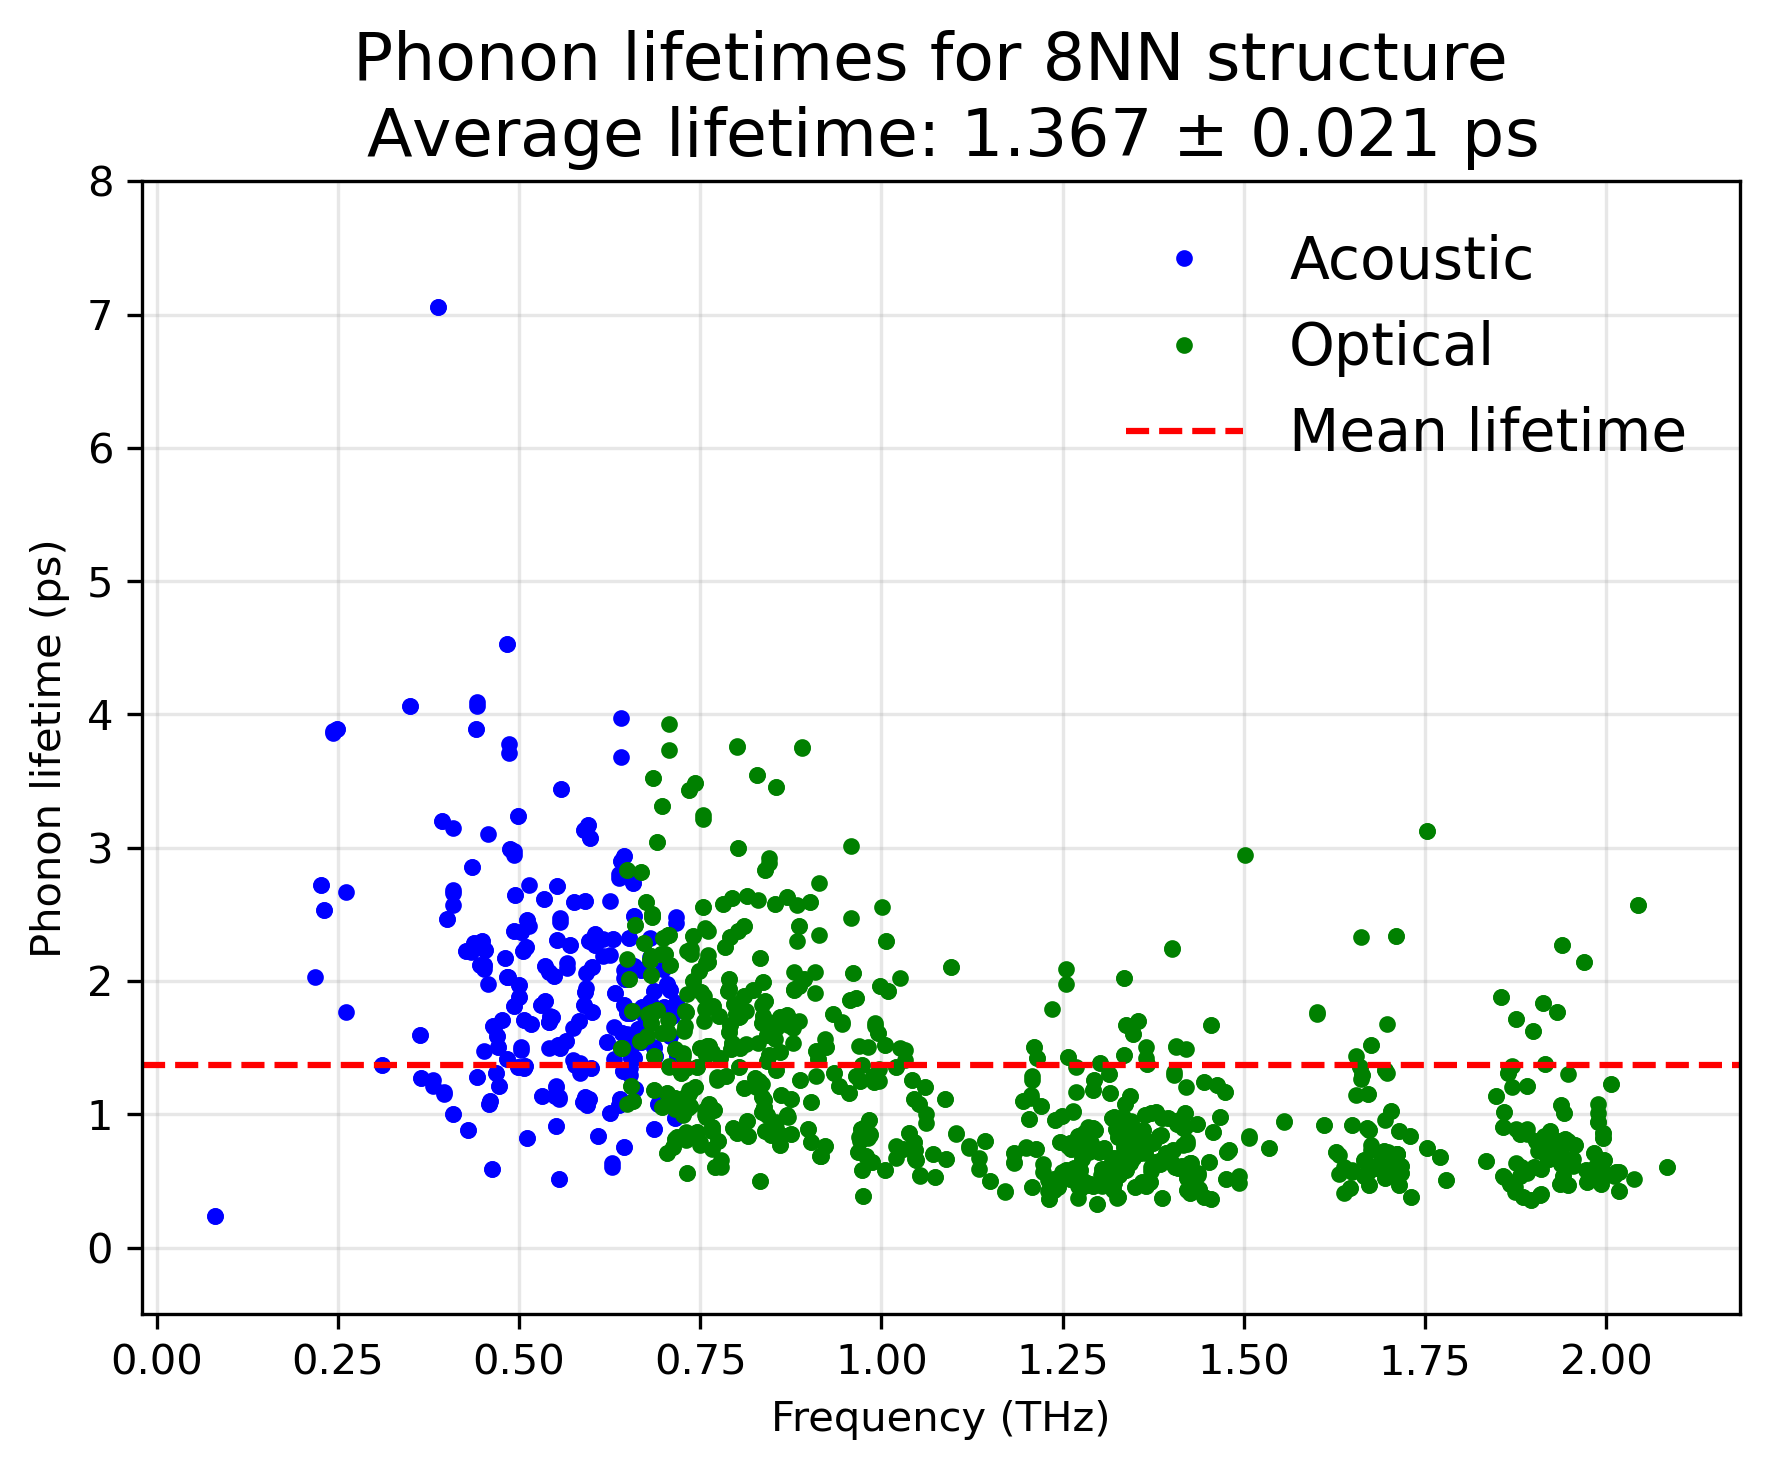

In [18]:
# Obtain all phonon lifetimes and convert to picoseconds (no 1e12 division)
# Note we only take those lifetimes for frequencies above the cutoff we identified earlier.
df = df[df["freq_THz"] > 1e-6]
all_lifetimes = 1 / (df["Width (THz)"] * 2 * np.pi)
# Correspondingly find the mean lifetime and its standard error std / sqrt N
mean_lifetime = all_lifetimes.mean()
sem_lifetime = all_lifetimes.std() / np.sqrt(len(all_lifetimes))

# Filter out acoustic phonons from optical ones
acoustic = df["s"] < 4

# Create plot of lifetime vs frequency
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(df[acoustic]["freq_THz"], all_lifetimes[acoustic], 'o', markersize=3, label="Acoustic", color="blue")
ax.plot(df[~acoustic]["freq_THz"], all_lifetimes[~acoustic], 'o', markersize=3, label="Optical", color="green")
ax.axhline(mean_lifetime, linestyle='--', color='red', label=f"Mean lifetime")
ax.set_xlabel("Frequency (THz)")
ax.set_ylabel("Phonon lifetime (ps)")
ax.set_title(f"Phonon lifetimes for 8NN structure \n Average lifetime: {mean_lifetime:.3f} $\\pm$ {sem_lifetime:.3f} ps", fontsize=16)
ax.legend(fontsize=14)
plt.ylim(-0.5, 8)
ax.grid(alpha=0.3)
plt.tight_layout()

### Directional phonon lifetime analysis

C:\Users\mohia\AppData\Local\Temp\ipykernel_2944\2830384040.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[["kx", "ky", "kz"]] = df["k_coordinates"].str.split(expand=True).astype(float)
C:\Users\mohia\AppData\Local\Temp\ipykernel_2944\2830384040.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[["kx", "ky", "kz"]] = df["k_coordinates"].str.split(expand=True).astype(float)
C:\Users\mohia\AppData\Local\Temp\ipykernel_2944\2830384040.py:2: SettingWithCopyWarning: 
A value is trying to be set on a 

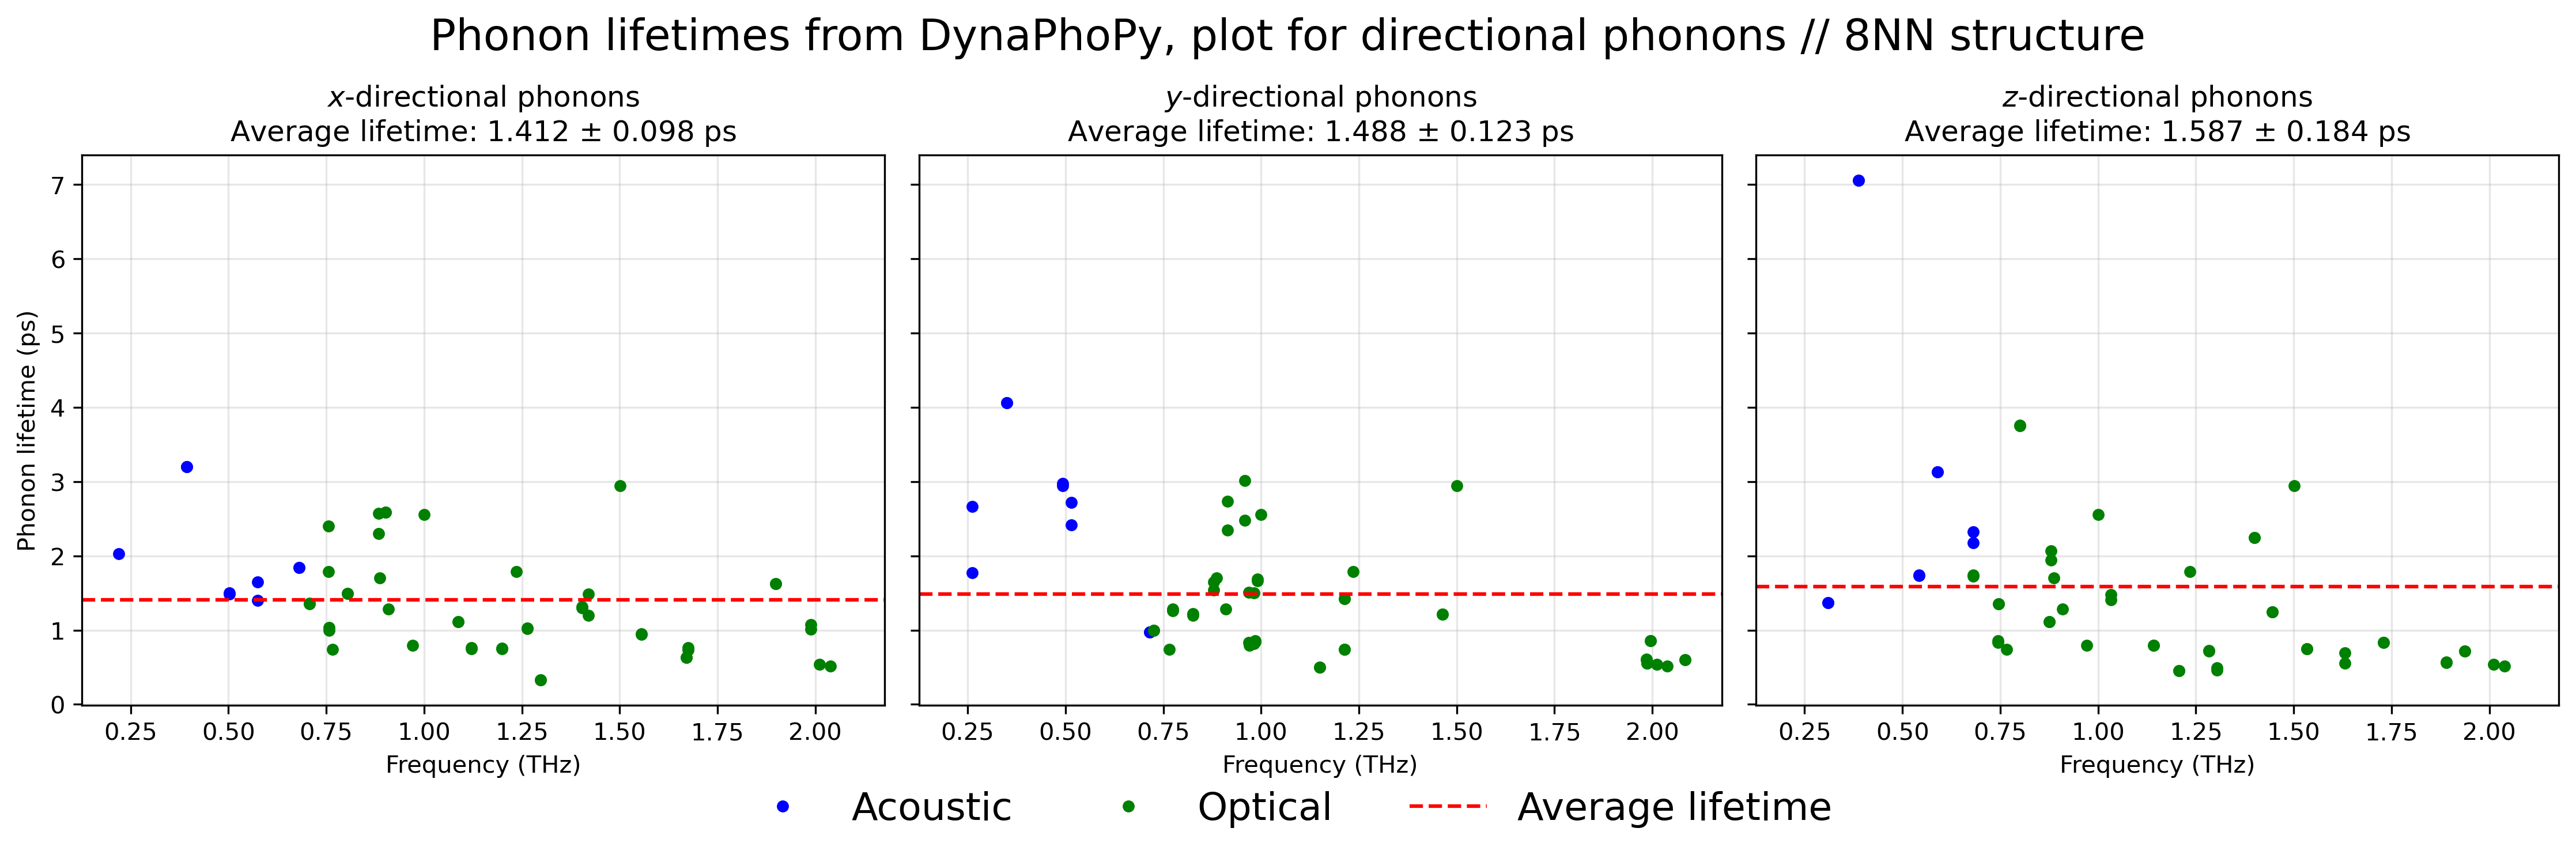

In [19]:
# Filter dataframe to extract only the purely x-, y- and z-directional phonons (definition of wavevector k)
df[["kx", "ky", "kz"]] = df["k_coordinates"].str.split(expand=True).astype(float)
df_x = df[["k", "s", "Width (THz)", "kx", "ky", "kz", "freq_THz"]][df["ky"] == 0][df["kz"] == 0]
df_y = df[["k", "s", "Width (THz)", "kx", "ky", "kz", "freq_THz"]][df["kx"] == 0][df["kz"] == 0]
df_z = df[["k", "s", "Width (THz)", "kx", "ky", "kz", "freq_THz"]][df["kx"] == 0][df["ky"] == 0]

##### x-directional phonons
# Find acoustic lifetimes
acoustic_linewidths_x = df_x[["s", "kx", "Width (THz)"]][df_x["s"] < 4]["Width (THz)"]
acoustic_lifetimes_x = 1/(acoustic_linewidths_x * 2 * np.pi)
acoustic_kx = df_x[["s", "kx", "Width (THz)"]][df_x["s"] < 4]["kx"]
# Find optical lifetimes
optical_linewidths_x = df_x[["s", "kx", "Width (THz)"]][df_x["s"] > 3]["Width (THz)"]
optical_lifetimes_x = 1/(optical_linewidths_x * 2 * np.pi)
optical_kx = df_x[["s", "kx", "Width (THz)"]][df_x["s"] > 3]["kx"]
##### y-directional phonons
# Find acoustic lifetimes
acoustic_linewidths_y = df_y[["s", "ky", "Width (THz)"]][df_y["s"] < 4]["Width (THz)"]
acoustic_lifetimes_y = 1/(acoustic_linewidths_y * 2 * np.pi)
acoustic_ky = df_y[["s", "ky", "Width (THz)"]][df_y["s"] < 4]["ky"]
# Find optical lifetimes
optical_linewidths_y = df_y[["s", "ky", "Width (THz)"]][df_y["s"] > 3]["Width (THz)"]
optical_lifetimes_y = 1/(optical_linewidths_y * 2 * np.pi)
optical_ky = df_y[["s", "ky", "Width (THz)"]][df_y["s"] > 3]["ky"]
##### z-directional phonons
# Find acoustic lifetimes
acoustic_linewidths_z = df_z[["s", "kz", "Width (THz)"]][df_z["s"] < 4]["Width (THz)"]
acoustic_lifetimes_z = 1/(acoustic_linewidths_z * 2 * np.pi)
acoustic_kz = df_z[["s", "kz", "Width (THz)"]][df_z["s"] < 4]["kz"]
# Find optical lifetimes
optical_linewidths_z = df_z[["s", "kz", "Width (THz)"]][df_z["s"] > 3]["Width (THz)"]
optical_lifetimes_z = 1/(optical_linewidths_z * 2 * np.pi)
optical_kz = df_z[["s", "kz", "Width (THz)"]][df_z["s"] > 3]["kz"]

##### Convert directional lifetimes to means
# x-direction
lifetimes_x = 1/(df_x["Width (THz)"] * 2 * np.pi)
x_mean_lifetime = lifetimes_x.mean()
x_sem_lifetime = lifetimes_x.std() / np.sqrt(len(lifetimes_x))
# y-direction
lifetimes_y = 1/(df_y["Width (THz)"] * 2 * np.pi)
y_mean_lifetime = lifetimes_y.mean()
y_sem_lifetime = lifetimes_y.std() / np.sqrt(len(lifetimes_y))
# z-direction
lifetimes_z = 1/(df_z["Width (THz)"] * 2 * np.pi)
z_mean_lifetime = lifetimes_z.mean()
z_sem_lifetime = lifetimes_z.std() / np.sqrt(len(lifetimes_z))

# Also extract the acoustic and optical frequencies which will form our x axis
acoustic_freq_x = df_x[df_x["s"] < 4]["freq_THz"].values
optical_freq_x = df_x[df_x["s"] >= 4]["freq_THz"].values
acoustic_freq_y = df_y[df_y["s"] < 4]["freq_THz"].values
optical_freq_y = df_y[df_y["s"] >= 4]["freq_THz"].values
acoustic_freq_z = df_z[df_z["s"] < 4]["freq_THz"].values
optical_freq_z = df_z[df_z["s"] >= 4]["freq_THz"].values

# Then, plot it!
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)
for ax, ac, op, fac, fop, mean, sem, label in zip(axes,
    [acoustic_lifetimes_x, acoustic_lifetimes_y, acoustic_lifetimes_z],
    [optical_lifetimes_x, optical_lifetimes_y, optical_lifetimes_z],
    [acoustic_freq_x, acoustic_freq_y, acoustic_freq_z],
    [optical_freq_x, optical_freq_y, optical_freq_z],
    [x_mean_lifetime, y_mean_lifetime, z_mean_lifetime],
    [x_sem_lifetime, y_sem_lifetime, z_sem_lifetime],
    ["x", "y", "z"]):
    # Plot acoustic
    ax.plot(fac, ac, 'o', markersize=4, label="Acoustic", color='blue')
    # Plot optical
    ax.plot(fop, op, 'o', markersize=4, label="Optical", color='green')
    # Plot mean line
    ax.axhline(mean, linestyle='--', color='red', label=f"Average lifetime")
    # Add labels and plot, make it look nicer
    ax.set_xlabel("Frequency (THz)")
    ax.set_title(f"${label}$-directional phonons\nAverage lifetime: {mean:.3f} $\\pm$ {sem:.3f} ps")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("Phonon lifetime (ps)")
# Put the legend at the bottom, as it is universal
handles, labels = axes[0].get_legend_handles_labels()
plt.suptitle("Phonon lifetimes from DynaPhoPy, plot for directional phonons // 8NN structure", fontsize=18)
fig.legend(handles, labels, loc="lower center", ncol=3, fontsize=16)
fig.tight_layout(rect=[0, 0.07, 1, 0.93])
plt.subplots_adjust(top=0.82)

## Phonon velocity analysis
Can't use the dataframe anymore, since these operators were derived externally!

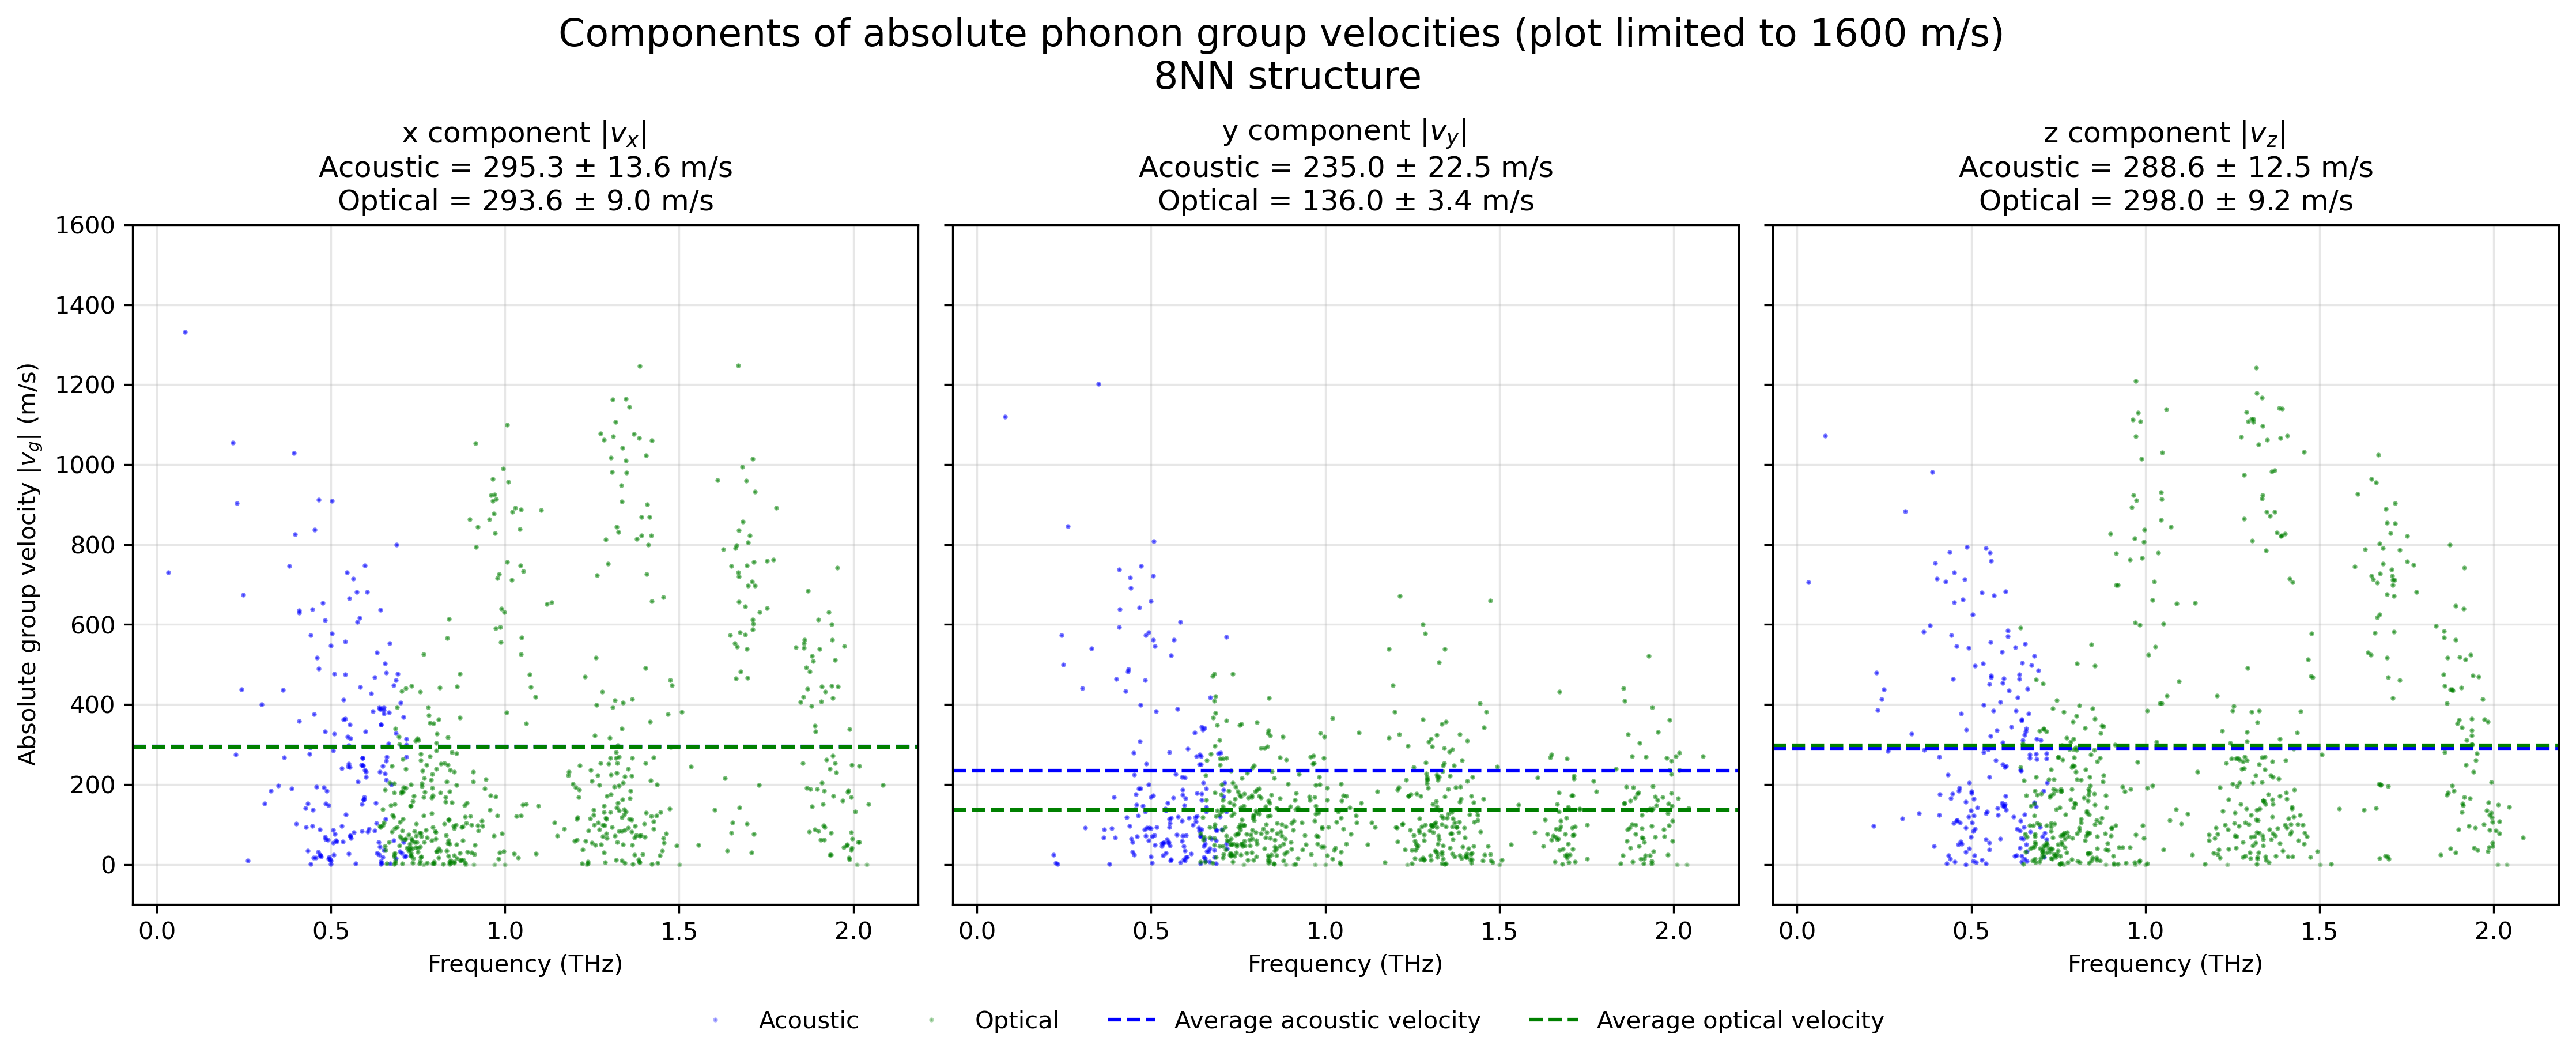

In [20]:
# Create figure for plotting
fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharex=True, sharey=True)
labels = ["x", "y", "z"]

# Loop over all axes (we will have 3, one for each direction)
for alpha, ax in enumerate(axes):
    # Set up acoustic and optical group velocities and frequency storage lists
    acoustic_vg = []; acoustic_freqs = []; optical_vg = []; optical_freqs = []

    # Loop over all phonon velocity operators (dependant on k and dyn mat size)
    # Also, is it dependant or dependent? Always confused me.
    for ik in range(num_k_points):
        for s in range(size_dynmat):
            # Extract group velocity (diagonal matrix elements), and also frequencies
            vg = np.abs(all_velocities_SI[ik, alpha, s, s].real)
            freq = all_frequencies_THz[ik, s]
            # If we are less than the cutoff, skip to next iteration of loop
            if freq < 1e-6:
                continue
            # Acoustic
            if s < 3:
                acoustic_vg.append(vg); acoustic_freqs.append(freq)
            # Optical
            else:
                optical_vg.append(vg); optical_freqs.append(freq)

    # Store acoustic and optical group vels, find their means and errors
    acoustic_vg = np.array(acoustic_vg); optical_vg = np.array(optical_vg)
    acoustic_mean = np.mean(acoustic_vg); acoustic_sem = ( np.std(acoustic_vg) / np.sqrt(len(acoustic_vg)) )
    optical_mean = np.mean(optical_vg); optical_sem = ( np.std(optical_vg) / np.sqrt(len(optical_vg)) )

    # Plot them
    ax.plot(acoustic_freqs, acoustic_vg, 'o', markersize=1, alpha=0.3, label="Acoustic", color="blue")
    ax.plot(optical_freqs, optical_vg, 'o', markersize=1, alpha=0.3, label="Optical", color="green")
    ax.axhline(acoustic_mean, linestyle='--', color="blue", label="Average acoustic velocity")
    ax.axhline(optical_mean, linestyle='--', color="green", label="Average optical velocity")
    ax.set_xlabel("Frequency (THz)")
    ax.set_title(f"{labels[alpha]} component $|v_{labels[alpha]}|$ \n"
                 f"Acoustic = {acoustic_mean:.1f} $\\pm$ {acoustic_sem:.1f} m/s\n"
                 f"Optical = {optical_mean:.1f} $\\pm$ {optical_sem:.1f} m/s")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Absolute group velocity $|v_g|$ (m/s)")
# Add legend outside the main plots, but to the bottom of the axis
handles, labels_leg = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_leg, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.02))
plt.suptitle("Components of absolute phonon group velocities (plot limited to 1600 m/s) \n8NN structure", y=0.98, fontsize=16)
plt.ylim(-100, 1600)
fig.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.subplots_adjust(top=0.78)

## Plot phonon dispersions

In [21]:
def track_LA_branch(dynmat, alpha, npoints):
    """Tracks the longitudinal acoustic (LA) branch using eigenvector overlap methods.
    Essentially, it considers the eigenvector of the dynamical matrix for all points the dispersion relation is plot for.
    From this, it identifies the eigenvector at k=0.1, where we compute the LA gradient of after, then it finds corresponding frequencies.
    It then computes the next eigenvector, at 0.1+dk, then identifies which eigenvalue, thus branch, is most similar to k=0.1.
    So we call this an "eigenvector overlap" method.
    We need to do this to combat the crossings of dispersion branches, which essentially mix the LA branches with other branches,
    at k-points close to X.
    
    Inputs:
    dynmat - dynamical matrix built from phonopy
    alpha - Cartesian component
    npoints - number of k-points of our dispersion relation
    
    Outputs:
    recorded - recorded eigenvalues due to this method
    k_values - values of k due to npoints
    """
    # Now we have to identify the LA branch. This will be the one which is positive throughout.
    k_values = np.linspace(0.001, 0.5, npoints) # Define list of k points
    all_freqs = []; all_evecs = []
    # For all k points, we evaluate the dynamical matrix to get the frequencies and importantly, corresponding eigenvectors
    for k_val in k_values:
        k = [0, 0, 0]
        k[alpha] = k_val
        dynmat.run(k)
        evals, evecs = np.linalg.eigh(dynmat.dynamical_matrix)
        # Convert eigenvalues of dynamical matrix to phonon frequencies (square root)
        freqs = np.sign(evals) * np.sqrt(np.abs(evals)) * unit_conversion_factor
        all_freqs.append(freqs); all_evecs.append(evecs)
    all_freqs = np.array(all_freqs); all_evecs = np.array(all_evecs)

    # Identify highest positive acoustic branch at k=0.1 (1/5X)
    k_idx = np.argmin(np.abs(k_values - 0.1)) # start by identifying the index of k closest to k=0.1
    freq_idx = all_freqs[k_idx] # extract corresponding frequency
    acoustic_idx = np.argsort(np.abs(freq_idx))[:3] # since we are only interested in acoustic branches
    branch_idx = None
    max_freq = 0
    # Identify, among the 3 acoustic branches, the one with the largest slope (so largest at k=0.1), with their corresponding frequencies
    for i in acoustic_idx:
        if freq_idx[i] > 0.01 and freq_idx[i] > max_freq:
            max_freq = freq_idx[i]
            branch_idx = i

    # We want to record the LA branch frequency at each k point. To do so, we use the folloiwng block of code
    recorded = np.zeros(npoints)
    recorded[k_idx] = all_freqs[k_idx, branch_idx] # record the frequency of the LA branch at k=0.1; this is what we currently have.
    current_evec = all_evecs[k_idx, :, branch_idx] # also extract the current eigenvector we are considering in k-space

    # Now we will go over all k points in reciprocal space
    for i in range(k_idx + 1, npoints):
        # For each k point, we find the overlap between the current eigenvector and all eigenvectors
        overlaps = np.abs(current_evec.conj() @ all_evecs[i]) ** 2
        # We do the above, since we are able to find the branch, from the overlap, which has the largest overlap
        # In other words, the largest overlap means that the current eigenvector is most similar to the next eigenvector we consider
        best = np.argmax(overlaps)
        # We then correspondingly extract the frequency and eigenvector of the updated one.
        recorded[i] = all_freqs[i, best]; current_evec = all_evecs[i, :, best]

    # Instead of going forwards, we now go backwards in k-space
    current_evec = all_evecs[k_idx, :, branch_idx]
    for i in range(k_idx - 1, -1, -1):
        # It is the same logic as last time.
        overlaps = np.abs(current_evec.conj() @ all_evecs[i]) ** 2
        best = np.argmax(overlaps)
        recorded[i] = all_freqs[i, best]
        current_evec = all_evecs[i, :, best]

    return recorded, k_values

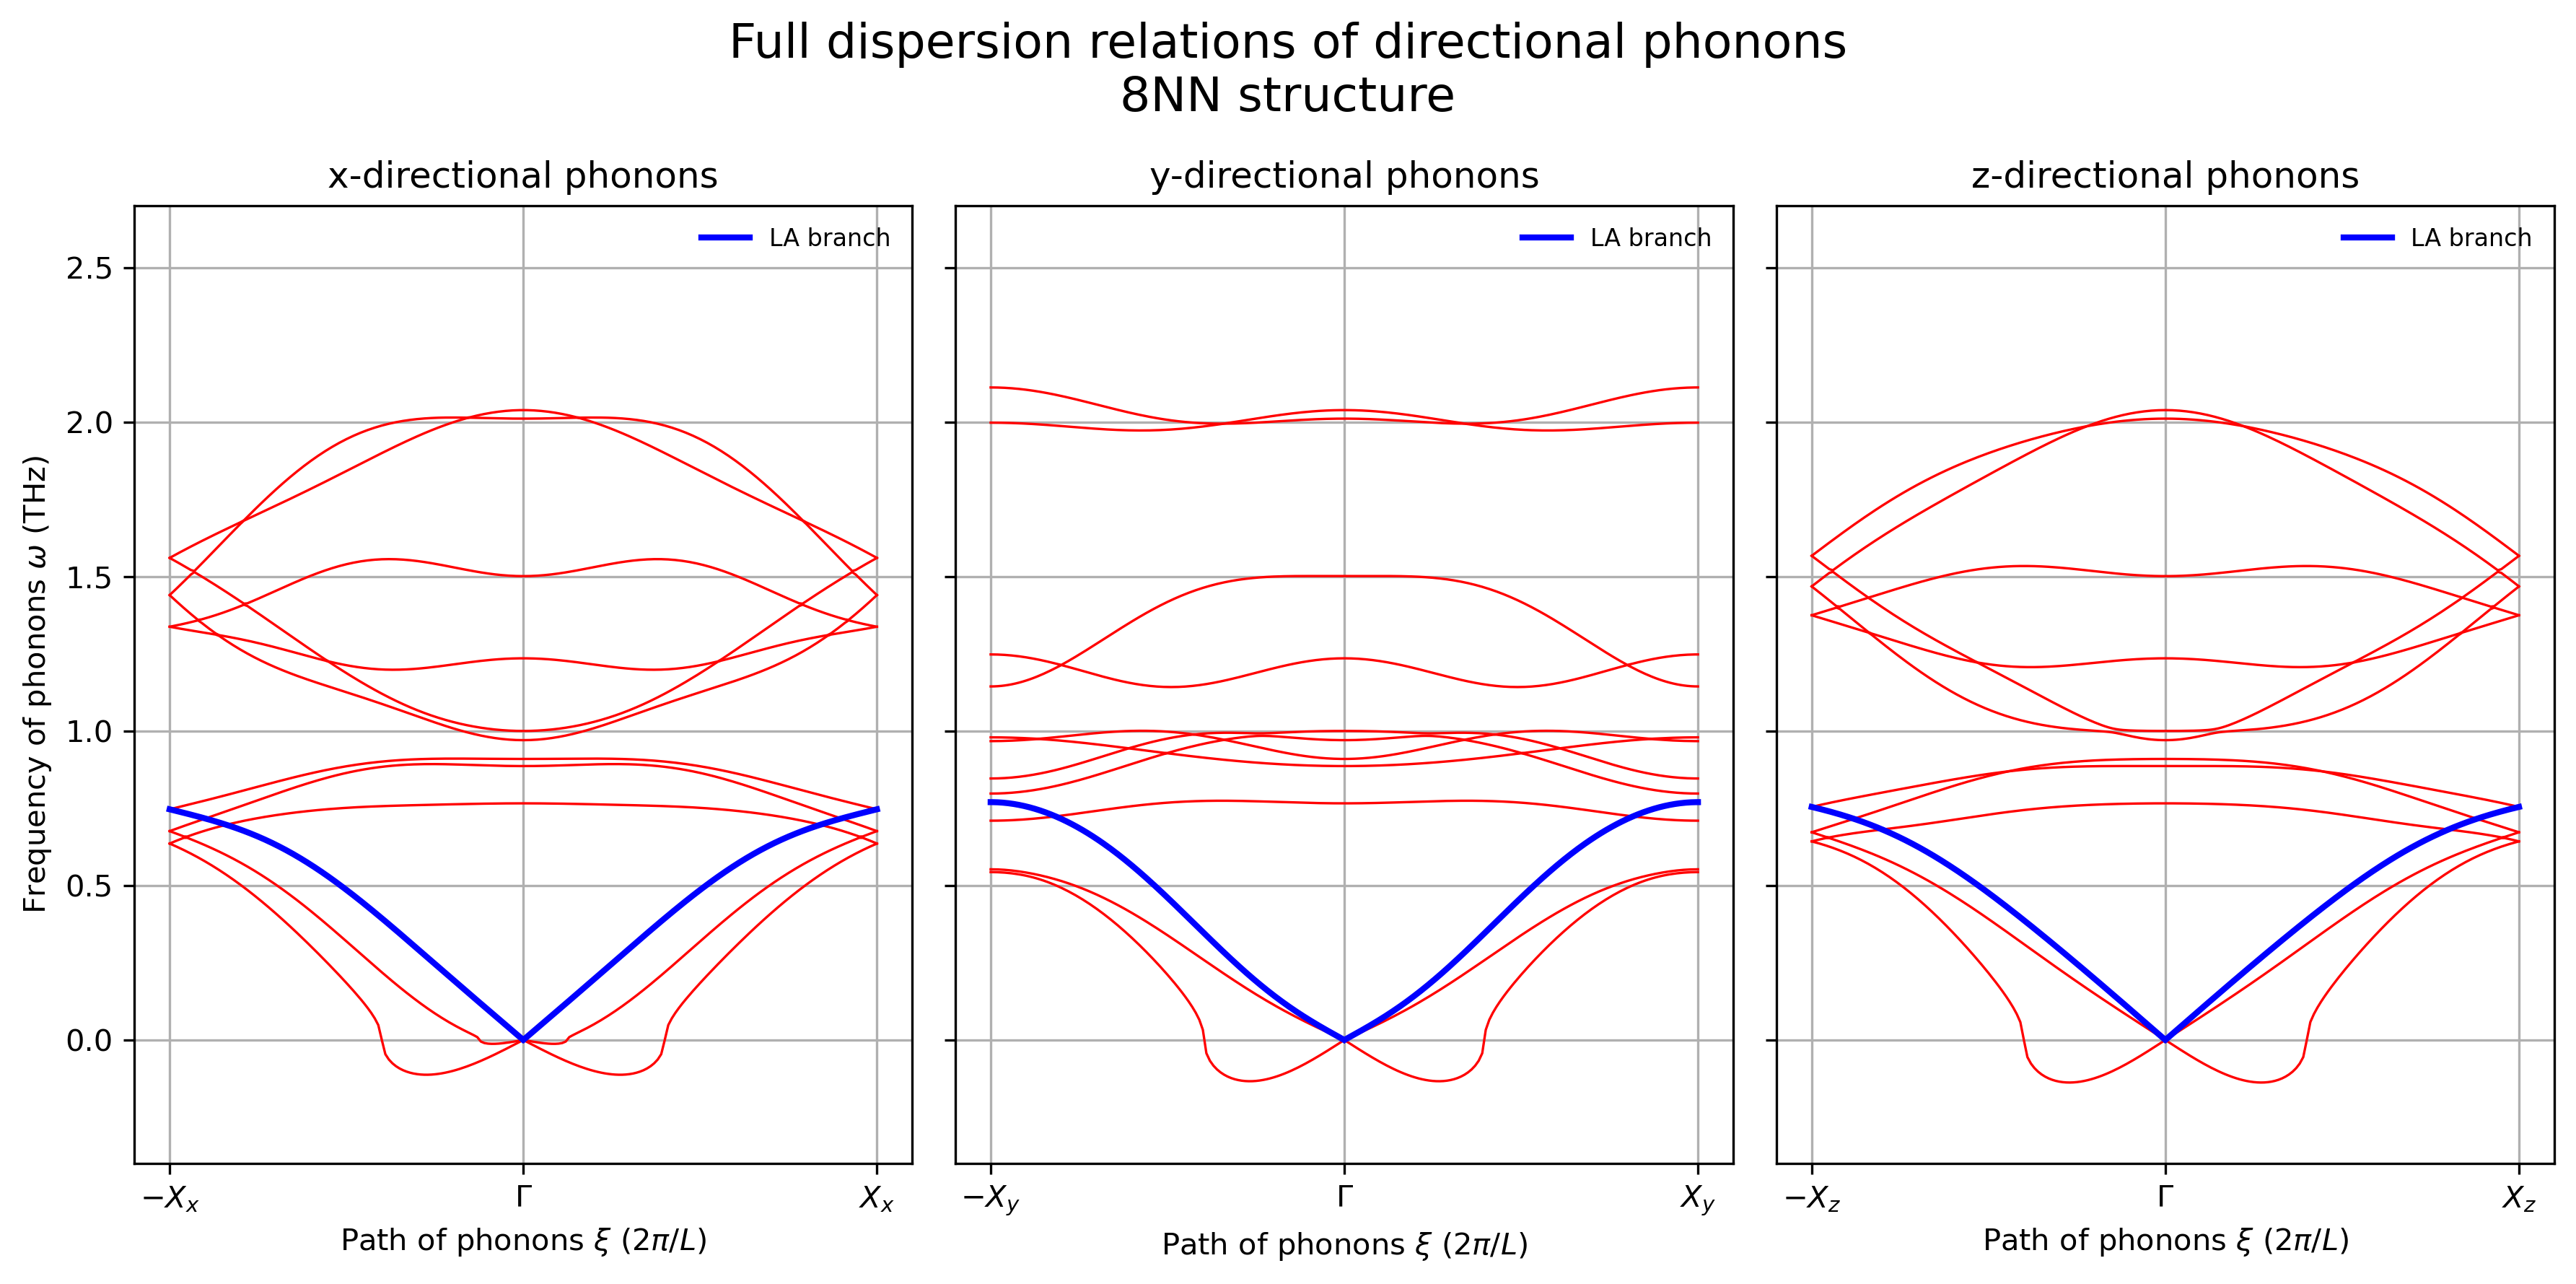

In [22]:
# We will interpolate our dispersion relations over 201 points between X -> Gamma -> X
npoints = 201
directions = [([-0.5, 0, 0], [0.5, 0, 0], "x", 0),
              ([0, -0.5, 0], [0, 0.5, 0], "y", 1),
              ([0, 0, -0.5], [0, 0, 0.5], "z", 2)]

# Create figure for plotting
fig, axes = plt.subplots(1, 3, figsize=(12, 6), sharey=True)

# Loop over Cartesian components, plot for the three directional phonons
for ax, (k_start, k_end, direction, alpha) in zip(axes, directions):
    # Identify k points
    k_points = np.linspace(k_start, k_end, npoints)
    # Obtain frequencies from k points
    freqs = np.array([phonon.get_frequencies(k) for k in k_points])
    # Define x axis for plotting
    x = np.linspace(-0.5, 0.5, npoints)
    # Plot the frequencies against this x, so we get the dispersion relations
    ax.plot(x, freqs, color="red", linewidth=0.8)

    # Identify and track the LA branch using eigenvector overlap
    recorded, k_values = track_LA_branch(dynmat, alpha, npoints)

    # Now, we have, from this identification, the frequencies, 'recorded', of the identified LA branch
    ax.plot(k_values, recorded, color="blue", linewidth=2, label="LA branch")
    ax.plot(-k_values, recorded, color="blue", linewidth=2)

    # Make the rest of the plot neater
    ax.set_title(f"{direction}-directional phonons")
    ax.set_xlabel(r"Path of phonons $\xi$ ($2\pi/L$)")
    ax.set_xticks([-0.5, 0, 0.5])
    ax.set_xticklabels([f"$-X_{direction}$", r"$\Gamma$", f"$X_{direction}$"])
    ax.grid()
    ax.legend(fontsize=8)

axes[0].set_ylabel(r"Frequency of phonons $\omega$ (THz)")
plt.suptitle("Full dispersion relations of directional phonons\n8NN structure", fontsize=16)
plt.ylim(-0.4, 2.7)
plt.tight_layout()

### Calculate slopes of LA branches

In [23]:
# Set up slopes storage
slopes = np.zeros(3)
# Loop over x y and z branches
for label, alpha in zip(["x", "y", "z"], [0, 1, 2]):
    # Set k to zero (Gamma point)
    k = [0, 0, 0]
    # Move to e.g. (0.1, 0, 0) in x iteration, then (0, 0.1, 0) in y iteration, ...
    k[alpha] = 0.1
    # Constructs the phonon group velocities essentially (there's something about this in phonopy documentation)
    phonon.run_qpoints([k], with_group_velocities=True)
    kdict = phonon.get_qpoints_dict()
    # Extract frequencies and group velocities
    freqs = kdict['frequencies'][0]; vg = kdict['group_velocities'][0]

    acoustic_idx = np.argsort(np.abs(freqs))[:3] # identify acoustic branches only, as we wish
    # Identical to LA branch identification: find the one with the highest frequency at k = 0.1, and this should be the LA branch
    branch_idx = None
    max_freq = 0
    for i in acoustic_idx:
        if freqs[i] > 0.01 and freqs[i] > max_freq:
            max_freq = freqs[i]
            branch_idx = i

    # Identify velocity from longitudinal acoustic branch after having found the LA branch
    v = np.abs(vg[branch_idx, alpha]) * 100
    print(f"{label}-direction: ω = {freqs[branch_idx]:.4f} THz, v = {v:.0f} m/s")
    slopes[alpha] = v

x-direction: ω = 0.1967 THz, v = 1067 m/s
y-direction: ω = 0.1446 THz, v = 943 m/s
z-direction: ω = 0.1980 THz, v = 1049 m/s


<>:20: SyntaxWarning: invalid escape sequence '\o'
<>:20: SyntaxWarning: invalid escape sequence '\o'
C:\Users\mohia\AppData\Local\Temp\ipykernel_2944\1138335923.py:20: SyntaxWarning: invalid escape sequence '\o'
  ax.set_ylabel("Frequency of phonons $\omega$ (THz)")


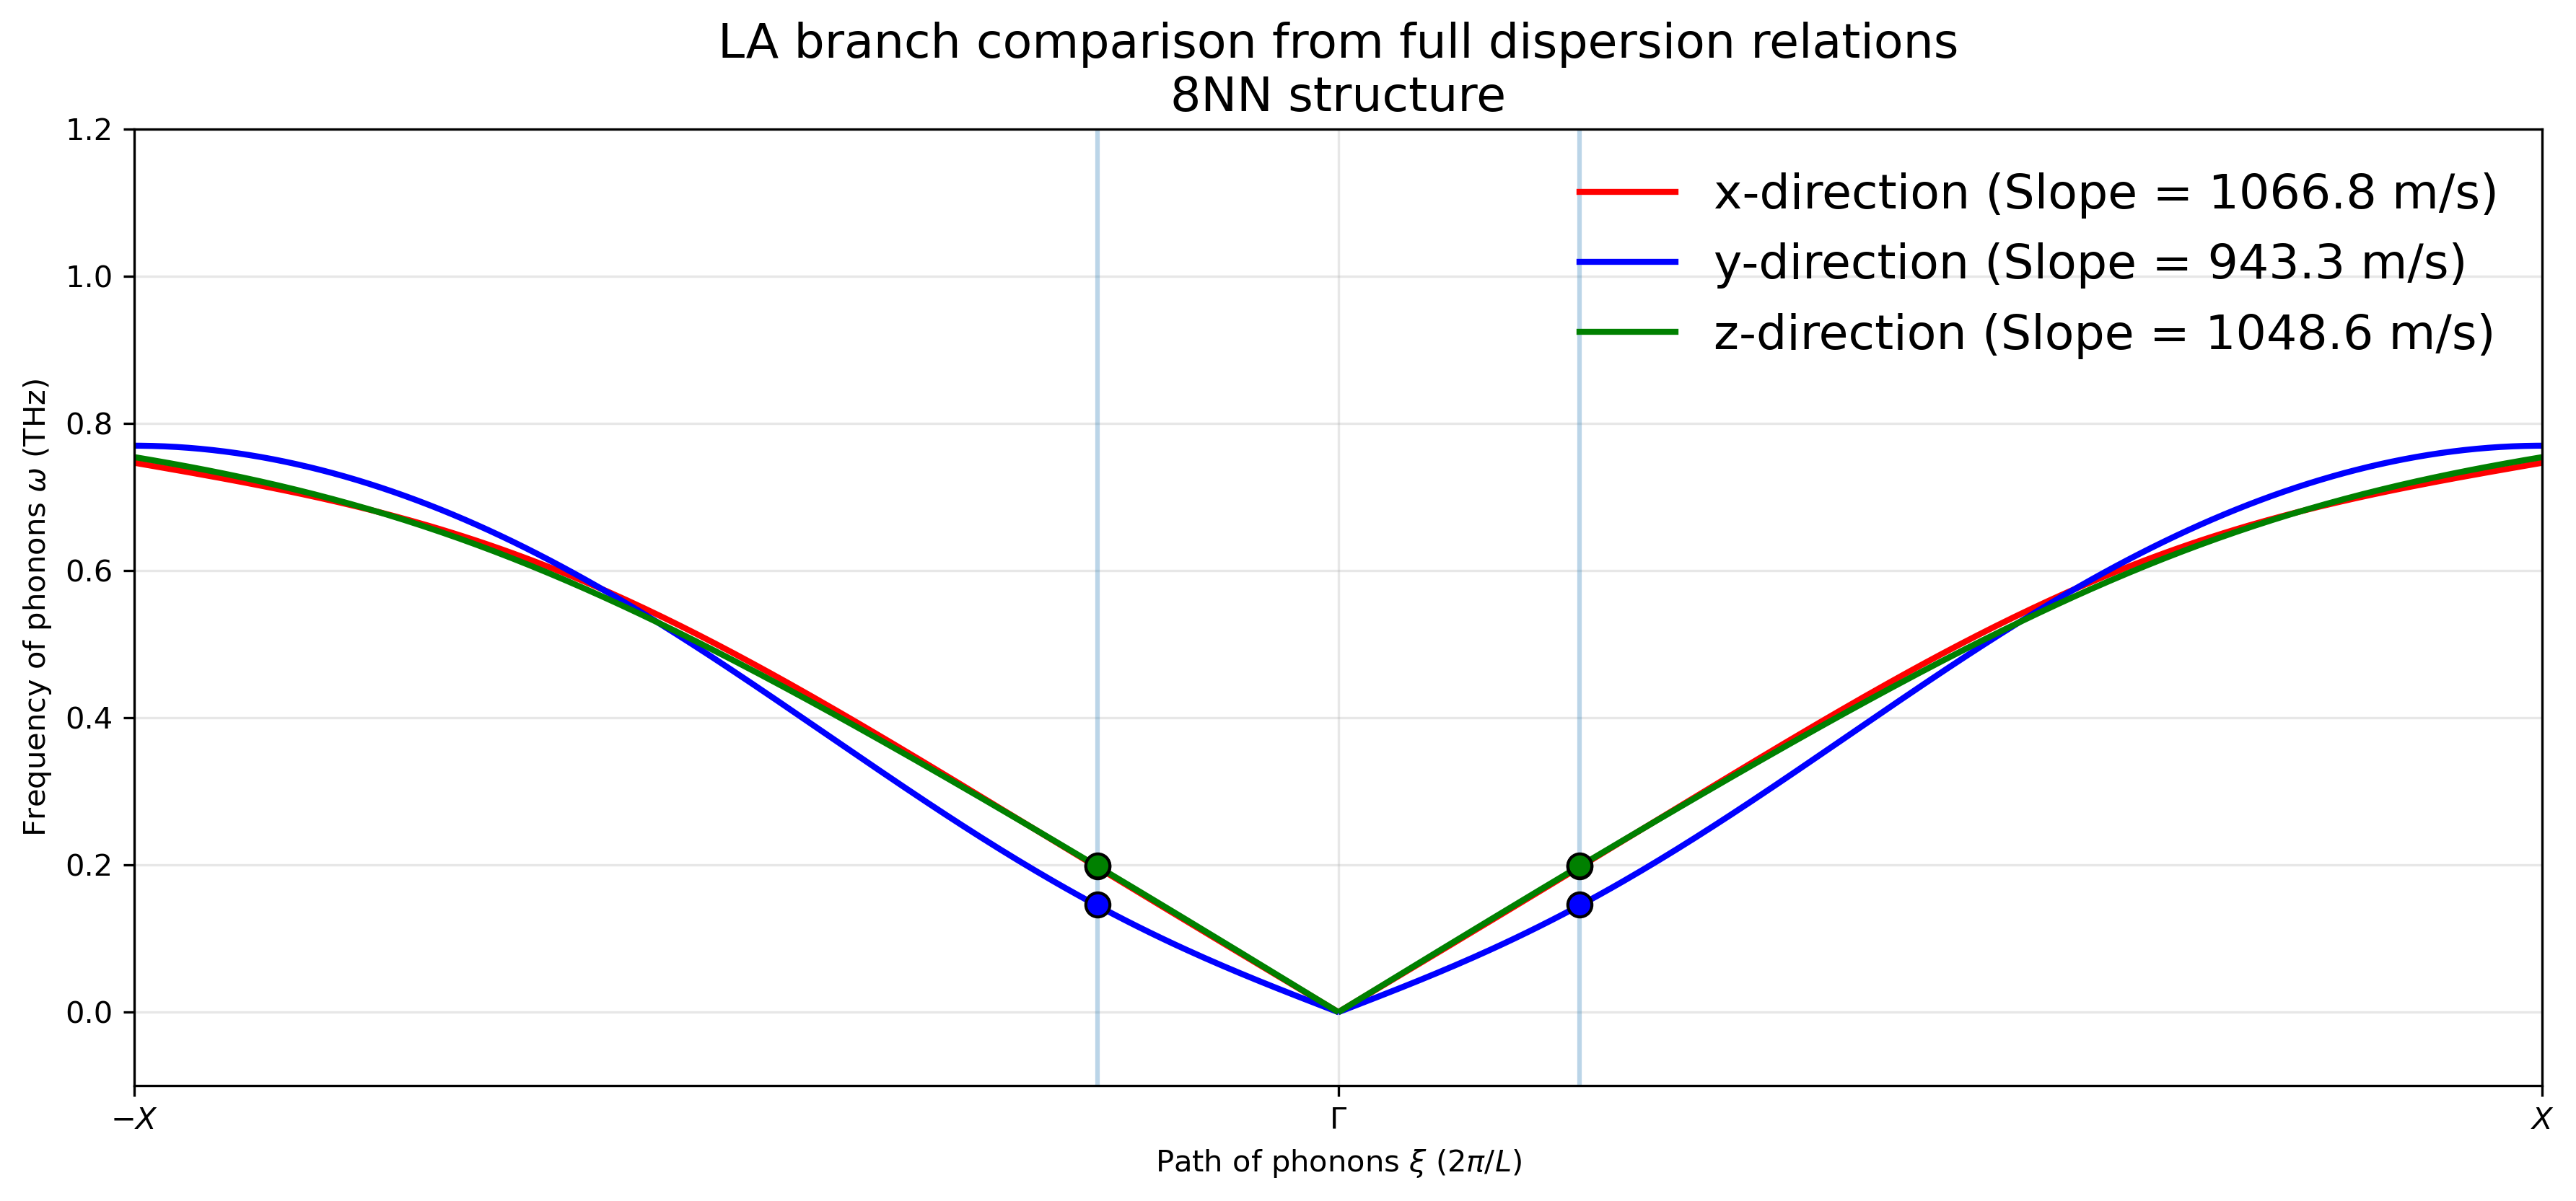

In [24]:
npoints = 201
fig, ax = plt.subplots(figsize=(12, 5.65))

# Plot LA branches of x y and z
for label, alpha, color, slope in zip(["x", "y", "z"], [0, 1, 2], ["red", "blue", "green"], slopes):
    recorded, k_values = track_LA_branch(dynmat, alpha, npoints)

    ax.plot(k_values, recorded, color=color, linewidth=2, label=f"{label}-direction (Slope = {slope:.1f} m/s)")
    ax.plot(-k_values, recorded, color=color, linewidth=2)

    # Mark k=0.1 points
    k_idx = np.argmin(np.abs(k_values - 0.1))
    freq_at_ref = recorded[k_idx]
    ax.plot(0.1, freq_at_ref, 'o', color=color, markersize=8, markeredgecolor='black', zorder=5)
    ax.plot(-0.1, freq_at_ref, 'o', color=color, markersize=8, markeredgecolor='black', zorder=5)

ax.axvline(0.1, alpha=0.3)
ax.axvline(-0.1, alpha=0.3)
ax.set_xlabel(r"Path of phonons $\xi$ ($2\pi/L$)")
ax.set_ylabel("Frequency of phonons $\omega$ (THz)")
ax.set_title("LA branch comparison from full dispersion relations\n8NN structure", fontsize=16)
ax.set_xticks([-0.5, 0, 0.5])
ax.set_xticklabels(["$-X$", r"$\Gamma$", "$X$"])
ax.set_xlim(-0.5, 0.5)
ax.legend(fontsize=16)
ax.grid(alpha=0.3)
plt.ylim(-0.1, 1.2)
plt.tight_layout()